In [1]:
!pip install pandas numpy matplotlib seaborn scikit-learn shap joblib


[notice] A new release of pip is available: 24.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [1]:
import os
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import joblib
import shap

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

warnings.filterwarnings("ignore")

print("All libraries imported successfully!")

All libraries imported successfully!


In [2]:
os.makedirs("models", exist_ok=True)
os.makedirs("outputs", exist_ok=True)

print("Folders created successfully!")

Folders created successfully!


In [3]:
df = pd.read_csv("data/titanic.csv")

print("Dataset loaded successfully!")
print("Shape:", df.shape)

Dataset loaded successfully!
Shape: (418, 12)


In [4]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,0,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,1,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,0,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,0,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,1,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Survived     418 non-null    int64  
 2   Pclass       418 non-null    int64  
 3   Name         418 non-null    str    
 4   Sex          418 non-null    str    
 5   Age          332 non-null    float64
 6   SibSp        418 non-null    int64  
 7   Parch        418 non-null    int64  
 8   Ticket       418 non-null    str    
 9   Fare         417 non-null    float64
 10  Cabin        91 non-null     str    
 11  Embarked     418 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 56.1 KB


In [6]:
print("columns in the dataset:")
print(df.columns.tolist())


columns in the dataset:
['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked']


In [7]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,418.000000,418.000000,418.000000,332.000000,418.000000,418.000000,417.000000
mean,1100.500000,0.363636,2.265550,30.272590,0.447368,0.392344,35.627188
std,120.810458,0.481622,0.841838,14.181209,0.896760,0.981429,55.907576
min,892.000000,0.000000,1.000000,0.170000,0.000000,0.000000,0.000000
25%,996.250000,0.000000,1.000000,21.000000,0.000000,0.000000,7.895800
50%,1100.500000,0.000000,3.000000,27.000000,0.000000,0.000000,14.454200
75%,1204.750000,1.000000,3.000000,39.000000,1.000000,0.000000,31.500000
max,1309.000000,1.000000,3.000000,76.000000,8.000000,9.000000,512.329200


In [8]:
missing_values = df.isnull().sum()

print("Missing values:")
print(missing_values)

Missing values:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age             86
SibSp            0
Parch            0
Ticket           0
Fare             1
Cabin          327
Embarked         0
dtype: int64


In [9]:
missing_percentage = (
    df.isnull().sum() / len(df)
) * 100

missing_table = pd.DataFrame({
    "Missing Count": df.isnull().sum(),
    "Missing Percentage": missing_percentage
})

missing_table.sort_values(
    by="Missing Percentage",
    ascending=False
)

,Missing Count,Missing Percentage
Cabin,327,78.229665
Age,86,20.574163
Fare,1,0.239234
PassengerId,0,0.000000
Name,0,0.000000
Pclass,0,0.000000
Survived,0,0.000000
Sex,0,0.000000
Parch,0,0.000000
SibSp,0,0.000000


In [10]:
print("Number of duplicate rows:")
print(df.duplicated().sum())

Number of duplicate rows:
0


In [11]:
print(df["Survived"].value_counts())

Survived
0    266
1    152
Name: count, dtype: int64


In [12]:
survival_percentage = (
    df["Survived"]
    .value_counts(normalize=True)
    * 100
)

print(survival_percentage)

Survived
0    63.636364
1    36.363636
Name: proportion, dtype: float64


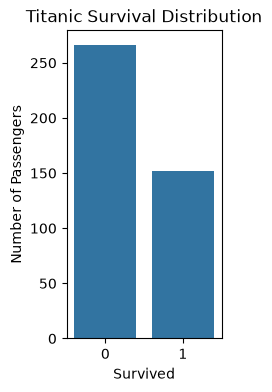

In [15]:
plt.figure(figsize=(2, 4))

sns.countplot(
    data=df,
    x="Survived"
)

plt.title("Titanic Survival Distribution")
plt.xlabel("Survived")
plt.ylabel("Number of Passengers")

plt.show()

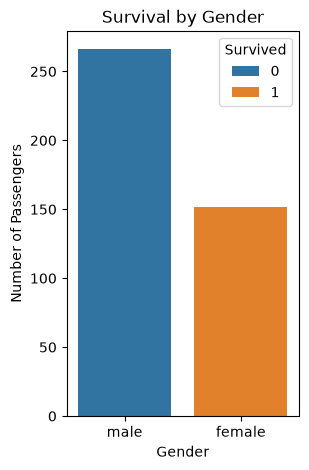

In [17]:
plt.figure(figsize=(3, 5))

sns.countplot(
    data=df,
    x="Sex",
    hue="Survived"
)

plt.title("Survival by Gender")
plt.xlabel("Gender")
plt.ylabel("Number of Passengers")

plt.show()

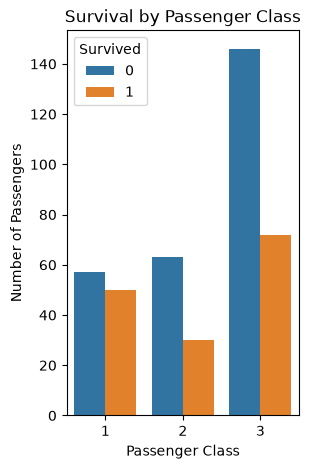

In [18]:
plt.figure(figsize=(3, 5))

sns.countplot(
    data=df,
    x="Pclass",
    hue="Survived"
)

plt.title("Survival by Passenger Class")
plt.xlabel("Passenger Class")
plt.ylabel("Number of Passengers")

plt.show()

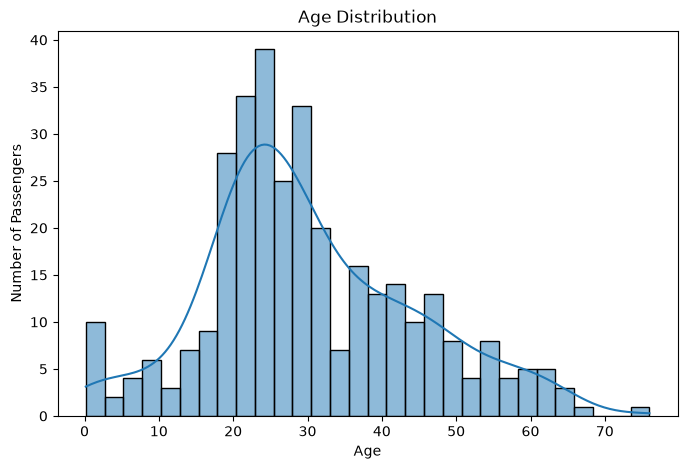

In [19]:
plt.figure(figsize=(8, 5))

sns.histplot(
    data=df,
    x="Age",
    bins=30,
    kde=True
)

plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Number of Passengers")

plt.show()

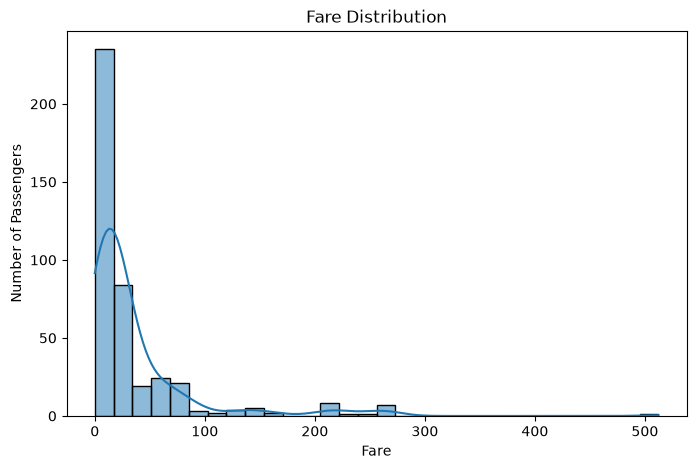

In [20]:
plt.figure(figsize=(8, 5))

sns.histplot(
    data=df,
    x="Fare",
    bins=30,
    kde=True
)

plt.title("Fare Distribution")
plt.xlabel("Fare")
plt.ylabel("Number of Passengers")

plt.show()

In [21]:
def create_features(data):
    
    data = data.copy()

    # -------------------------
    # Extract Title
    # -------------------------
    data["Title"] = data["Name"].str.extract(
        r",\s*([^.]*)\.",
        expand=False
    )

    data["Title"] = data["Title"].str.strip()

    # Group uncommon titles
    common_titles = [
        "Mr",
        "Miss",
        "Mrs",
        "Master"
    ]

    data["Title"] = data["Title"].apply(
        lambda x: x if x in common_titles else "Rare"
    )

    # -------------------------
    # Family Size
    # -------------------------
    data["FamilySize"] = (
        data["SibSp"] +
        data["Parch"] +
        1
    )

    # -------------------------
    # Is Alone
    # -------------------------
    data["IsAlone"] = (
        data["FamilySize"] == 1
    ).astype(int)

    # -------------------------
    # Cabin Presence
    # -------------------------
    data["HasCabin"] = (
        data["Cabin"].notna()
    ).astype(int)

    # -------------------------
    # Cabin Deck
    # -------------------------
    data["CabinDeck"] = (
        data["Cabin"]
        .fillna("Unknown")
        .str[0]
    )

    # -------------------------
    # Fare per Person
    # -------------------------
    data["FarePerPerson"] = (
        data["Fare"] /
        data["FamilySize"]
    )

    return data

In [22]:
df = create_features(df)

print("Feature engineering completed!")

Feature engineering completed!


In [23]:
df[
    [
        "Name",
        "Title",
        "FamilySize",
        "IsAlone",
        "HasCabin",
        "CabinDeck",
        "FarePerPerson"
    ]
].head(10)

,Name,Title,FamilySize,IsAlone,HasCabin,CabinDeck,FarePerPerson
0,"Kelly, Mr. James",Mr,1,1,0,U,7.829200
1,"Wilkes, Mrs. James (Ellen Needs)",Mrs,2,0,0,U,3.500000
2,"Myles, Mr. Thomas Francis",Mr,1,1,0,U,9.687500
3,"Wirz, Mr. Albert",Mr,1,1,0,U,8.662500
4,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",Mrs,3,0,0,U,4.095833
5,"Svensson, Mr. Johan Cervin",Mr,1,1,0,U,9.225000
6,"Connolly, Miss. Kate",Miss,1,1,0,U,7.629200
7,"Caldwell, Mr. Albert Francis",Mr,3,0,0,U,9.666667
8,"Abrahim, Mrs. Joseph (Sophie Halaut Easu)",Mrs,1,1,0,U,7.229200
9,"Davies, Mr. John Samuel",Mr,3,0,0,U,8.050000


In [24]:
print(df["Title"].value_counts())

Title
Mr        240
Miss       78
Mrs        72
Master     21
Rare        7
Name: count, dtype: int64


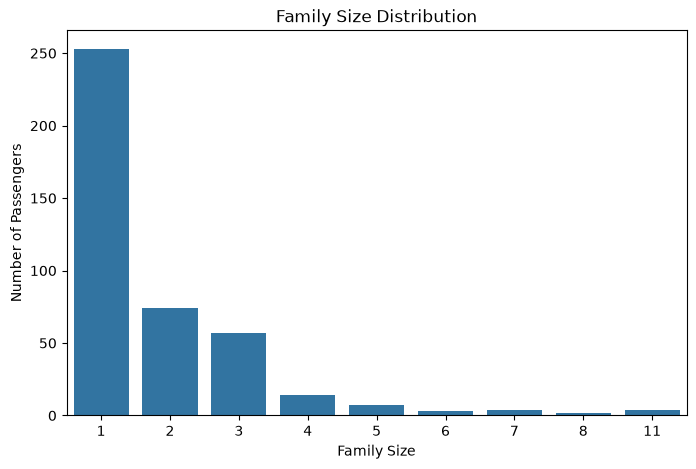

In [25]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="FamilySize"
)

plt.title("Family Size Distribution")
plt.xlabel("Family Size")
plt.ylabel("Number of Passengers")

plt.show()

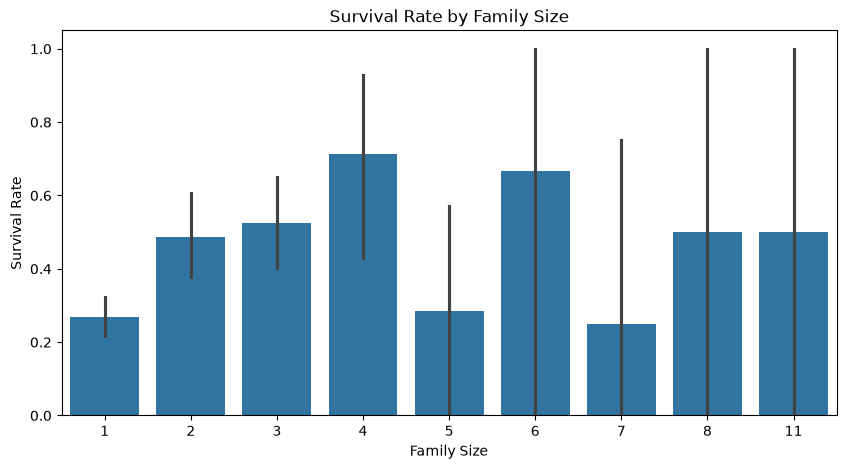

In [26]:
plt.figure(figsize=(10, 5))

sns.barplot(
    data=df,
    x="FamilySize",
    y="Survived"
)

plt.title("Survival Rate by Family Size")
plt.xlabel("Family Size")
plt.ylabel("Survival Rate")

plt.show()

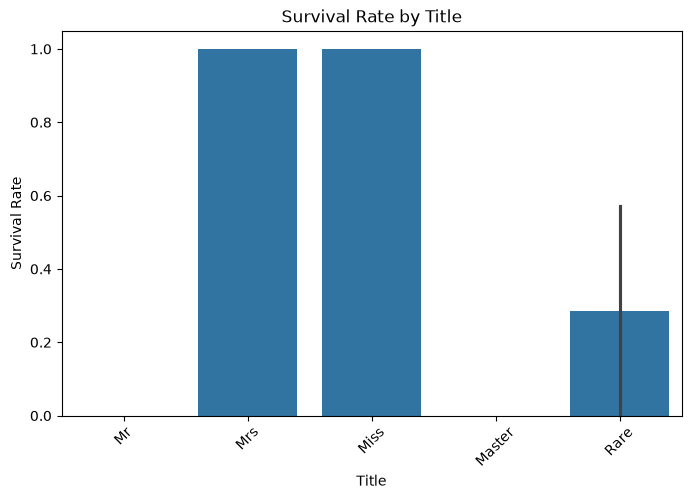

In [29]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=df,
    x="Title",
    y="Survived"
)

plt.title("Survival Rate by Title")
plt.xlabel("Title")
plt.ylabel("Survival Rate")

plt.xticks(rotation=45)

plt.show()

In [30]:
features = [
    "Pclass",
    "Sex",
    "Age",
    "SibSp",
    "Parch",
    "Fare",
    "Embarked",
    "Title",
    "FamilySize",
    "IsAlone",
    "HasCabin",
    "CabinDeck",
    "FarePerPerson"
]

X = df[features]

y = df["Survived"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (418, 13)
y shape: (418,)


In [31]:
X.head()

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,Title,FamilySize,IsAlone,HasCabin,CabinDeck,FarePerPerson
0,3,male,34.5,0,0,7.8292,Q,Mr,1,1,0,U,7.829200
1,3,female,47.0,1,0,7.0000,S,Mrs,2,0,0,U,3.500000
2,2,male,62.0,0,0,9.6875,Q,Mr,1,1,0,U,9.687500
3,3,male,27.0,0,0,8.6625,S,Mr,1,1,0,U,8.662500
4,3,female,22.0,1,1,12.2875,S,Mrs,3,0,0,U,4.095833


In [32]:
y.head()

0    0
1    1
2    0
3    0
4    1
Name: Survived, dtype: int64

In [33]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (334, 13)
Testing data: (84, 13)


In [34]:
numeric_features = [
    "Pclass",
    "Age",
    "SibSp",
    "Parch",
    "Fare",
    "FamilySize",
    "IsAlone",
    "HasCabin",
    "FarePerPerson"
]

In [35]:
categorical_features = [
    "Sex",
    "Embarked",
    "Title",
    "CabinDeck"
]

In [36]:
numeric_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="median")
        )
    ]
)

print("Numerical preprocessing created.")

Numerical preprocessing created.


In [37]:
categorical_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="most_frequent")
        ),
        (
            "encoder",
            OneHotEncoder(
                handle_unknown="ignore"
            )
        )
    ]
)

print("Categorical preprocessing created.")

Categorical preprocessing created.


In [38]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            numeric_transformer,
            numeric_features
        ),
        (
            "cat",
            categorical_transformer,
            categorical_features
        )
    ]
)

print("Preprocessor created successfully.")

Preprocessor created successfully.


In [39]:
models = {

    "Logistic Regression":
        LogisticRegression(
            max_iter=1000
        ),

    "Random Forest":
        RandomForestClassifier(
            n_estimators=300,
            max_depth=8,
            min_samples_split=5,
            random_state=42
        ),

    "Gradient Boosting":
        GradientBoostingClassifier(
            n_estimators=200,
            learning_rate=0.05,
            max_depth=3,
            random_state=42
        )
}

print("Models created:")
print(list(models.keys()))

Models created:
['Logistic Regression', 'Random Forest', 'Gradient Boosting']


In [40]:
trained_models = {}

results = []

for model_name, model in models.items():

    print("\nTraining:", model_name)

    pipeline = Pipeline(
        steps=[
            (
                "preprocessor",
                preprocessor
            ),
            (
                "model",
                model
            )
        ]
    )

    pipeline.fit(
        X_train,
        y_train
    )

    trained_models[model_name] = pipeline

    print(
        model_name,
        "training completed!"
    )


Training: Logistic Regression
Logistic Regression training completed!

Training: Random Forest
Random Forest training completed!

Training: Gradient Boosting
Gradient Boosting training completed!


In [41]:
for model_name, model in trained_models.items():

    y_pred = model.predict(X_test)

    y_prob = model.predict_proba(
        X_test
    )[:, 1]

    accuracy = accuracy_score(
        y_test,
        y_pred
    )

    precision = precision_score(
        y_test,
        y_pred
    )

    recall = recall_score(
        y_test,
        y_pred
    )

    f1 = f1_score(
        y_test,
        y_pred
    )

    roc_auc = roc_auc_score(
        y_test,
        y_prob
    )

    results.append({
        "Model": model_name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1,
        "ROC AUC": roc_auc
    })

results_df = pd.DataFrame(results)

results_df

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,Logistic Regression,1.0,1.0,1.0,1.0,1.0
1,Random Forest,1.0,1.0,1.0,1.0,1.0
2,Gradient Boosting,1.0,1.0,1.0,1.0,1.0


In [42]:
results_df.sort_values(
    by="F1 Score",
    ascending=False
)

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,Logistic Regression,1.0,1.0,1.0,1.0,1.0
1,Random Forest,1.0,1.0,1.0,1.0,1.0
2,Gradient Boosting,1.0,1.0,1.0,1.0,1.0


In [43]:
results_df.to_csv(
    "outputs/model_comparison.csv",
    index=False
)

print("Model comparison saved successfully!")

Model comparison saved successfully!


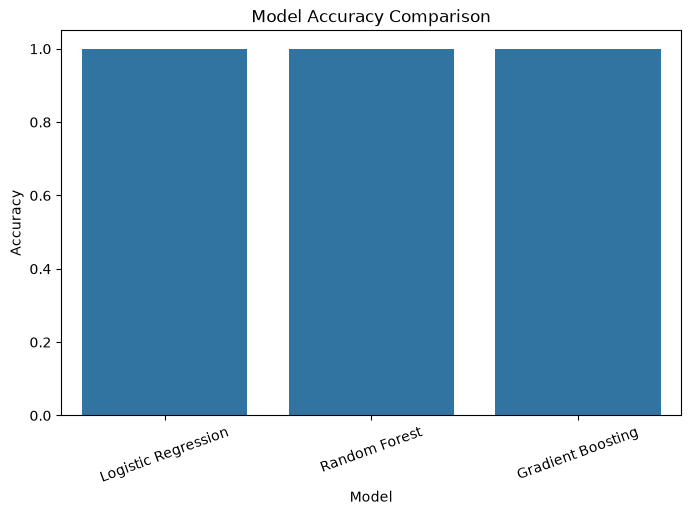

In [45]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=results_df,
    x="Model",
    y="Accuracy"
)

plt.title("Model Accuracy Comparison")
plt.xlabel("Model")
plt.ylabel("Accuracy")

plt.xticks(rotation=20)

plt.show()

In [46]:
best_model_name = (
    results_df
    .sort_values(
        by="F1 Score",
        ascending=False
    )
    .iloc[0]["Model"]
)

best_model = trained_models[
    best_model_name
]

print("Best model:")
print(best_model_name)

Best model:
Logistic Regression


In [47]:
best_predictions = best_model.predict(
    X_test
)

best_probabilities = (
    best_model.predict_proba(
        X_test
    )[:, 1]
)

print("Predictions generated successfully!")

Predictions generated successfully!


In [48]:
print(
    classification_report(
        y_test,
        best_predictions
    )
)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        53
           1       1.00      1.00      1.00        31

    accuracy                           1.00        84
   macro avg       1.00      1.00      1.00        84
weighted avg       1.00      1.00      1.00        84



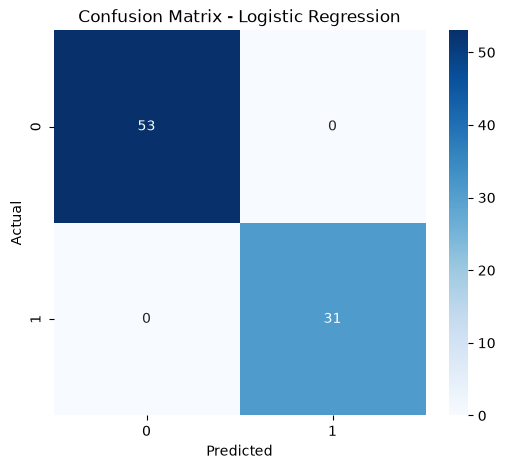

In [51]:
cm = confusion_matrix(
    y_test,
    best_predictions
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title(
    f"Confusion Matrix - {best_model_name}"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [52]:
fitted_preprocessor = (
    best_model
    .named_steps["preprocessor"]
)

feature_names = (
    fitted_preprocessor
    .get_feature_names_out()
)

print("Number of transformed features:")
print(len(feature_names))

print("\nFeature names:")
print(feature_names)

Number of transformed features:
27

Feature names:
['num__Pclass' 'num__Age' 'num__SibSp' 'num__Parch' 'num__Fare'
 'num__FamilySize' 'num__IsAlone' 'num__HasCabin' 'num__FarePerPerson'
 'cat__Sex_female' 'cat__Sex_male' 'cat__Embarked_C' 'cat__Embarked_Q'
 'cat__Embarked_S' 'cat__Title_Master' 'cat__Title_Miss' 'cat__Title_Mr'
 'cat__Title_Mrs' 'cat__Title_Rare' 'cat__CabinDeck_A' 'cat__CabinDeck_B'
 'cat__CabinDeck_C' 'cat__CabinDeck_D' 'cat__CabinDeck_E'
 'cat__CabinDeck_F' 'cat__CabinDeck_G' 'cat__CabinDeck_U']


In [53]:
model_object = (
    best_model
    .named_steps["model"]
)

if hasattr(
    model_object,
    "feature_importances_"
):

    importance_values = (
        model_object
        .feature_importances_
    )

    feature_importance = pd.DataFrame({
        "Feature": feature_names,
        "Importance": importance_values
    })

    feature_importance = (
        feature_importance
        .sort_values(
            by="Importance",
            ascending=False
        )
    )

    feature_importance.head(15)

else:

    print(
        "This model does not provide "
        "feature_importances_."
    )

This model does not provide feature_importances_.


In [54]:
if hasattr(
    model_object,
    "feature_importances_"
):

    top_features = (
        feature_importance
        .head(15)
        .sort_values(
            by="Importance"
        )
    )

    plt.figure(figsize=(10, 7))

    plt.barh(
        top_features["Feature"],
        top_features["Importance"]
    )

    plt.title(
        "Top 15 Feature Importances"
    )

    plt.xlabel("Importance")

    plt.ylabel("Feature")

    plt.tight_layout()

    plt.show()

In [55]:
if hasattr(
    model_object,
    "feature_importances_"
):

    feature_importance.to_csv(
        "outputs/feature_importance.csv",
        index=False
    )

    print(
        "Feature importance saved!"
    )

In [56]:
rf_pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "model",
            RandomForestClassifier(
                n_estimators=300,
                max_depth=8,
                min_samples_split=5,
                random_state=42
            )
        )
    ]
)

rf_pipeline.fit(
    X_train,
    y_train
)

print("Random Forest trained for SHAP!")

Random Forest trained for SHAP!


In [57]:
X_test_transformed = (
    rf_pipeline
    .named_steps["preprocessor"]
    .transform(X_test)
)

print(
    "Transformed test data shape:",
    X_test_transformed.shape
)

Transformed test data shape: (84, 27)


In [58]:
rf_model = (
    rf_pipeline
    .named_steps["model"]
)

print(rf_model)

RandomForestClassifier(max_depth=8, min_samples_split=5, n_estimators=300,
                       random_state=42)


In [59]:
explainer = shap.TreeExplainer(
    rf_model
)

print("SHAP explainer created!")

SHAP explainer created!


In [60]:
shap_values = explainer.shap_values(
    X_test_transformed
)

print("SHAP values calculated!")

SHAP values calculated!


In [61]:
if isinstance(shap_values, list):

    if len(shap_values) == 2:
        shap_for_plot = shap_values[1]
    else:
        shap_for_plot = shap_values[0]

else:

    if len(shap_values.shape) == 3:
        shap_for_plot = shap_values[:, :, 1]
    else:
        shap_for_plot = shap_values

print(
    "SHAP array shape:",
    shap_for_plot.shape
)

SHAP array shape: (84, 27)


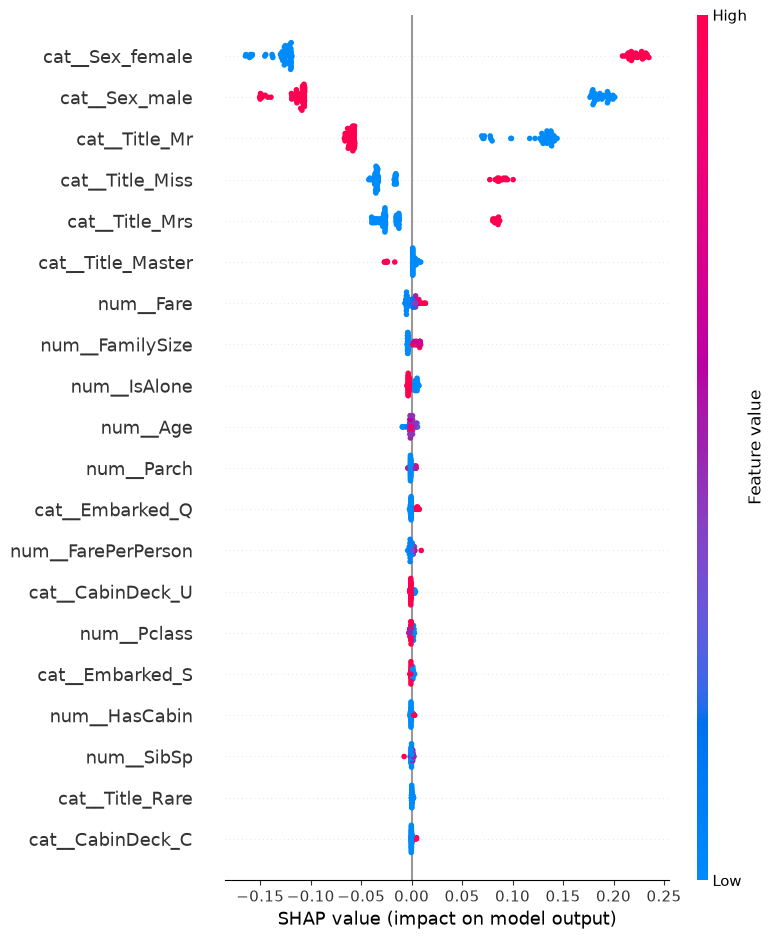

In [62]:
shap.summary_plot(
    shap_for_plot,
    X_test_transformed,
    feature_names=feature_names
)

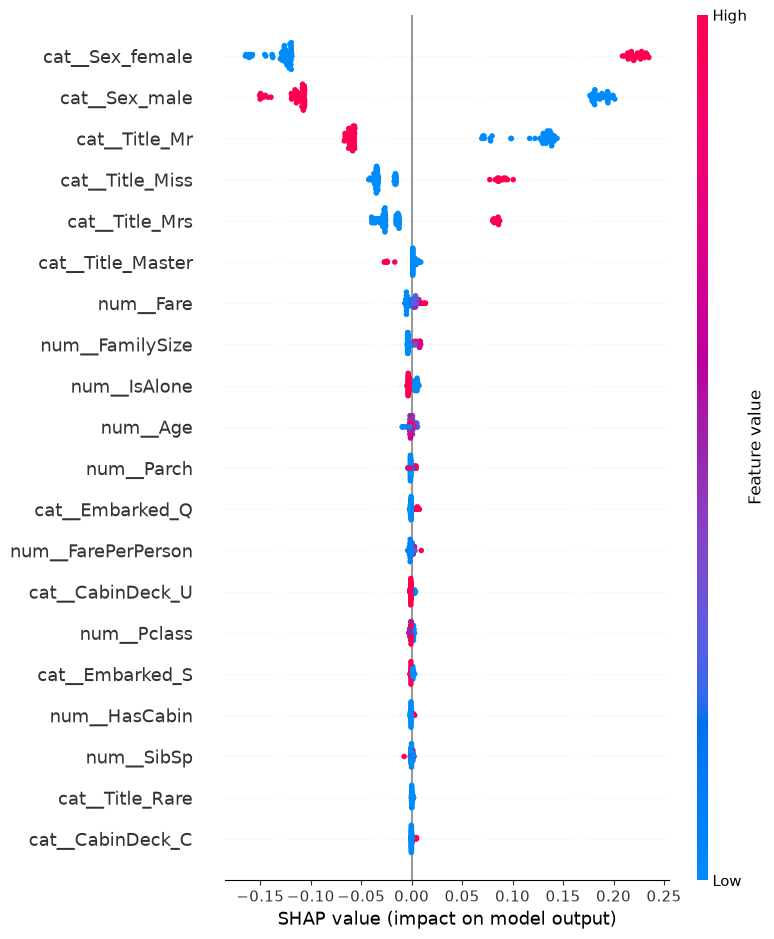

SHAP plot saved successfully!


In [63]:
plt.figure()

shap.summary_plot(
    shap_for_plot,
    X_test_transformed,
    feature_names=feature_names,
    show=False
)

plt.tight_layout()

plt.savefig(
    "outputs/shap_summary.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("SHAP plot saved successfully!")

In [64]:
joblib.dump(
    rf_pipeline,
    "models/titanic_model.pkl"
)

print(
    "Model saved successfully!"
)

print(
    "Location: models/titanic_model.pkl"
)

Model saved successfully!
Location: models/titanic_model.pkl


In [65]:
loaded_model = joblib.load(
    "models/titanic_model.pkl"
)

print("Saved model loaded successfully!")

Saved model loaded successfully!


In [66]:
new_passenger = pd.DataFrame([
    {
        "PassengerId": 999,
        "Pclass": 1,
        "Name": "Example, Mrs. Jane Smith",
        "Sex": "female",
        "Age": 30,
        "SibSp": 0,
        "Parch": 1,
        "Ticket": "TEST123",
        "Fare": 75.0,
        "Cabin": "C85",
        "Embarked": "S"
    }
])

new_passenger

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,999,1,"Example, Mrs. Jane Smith",female,30,0,1,TEST123,75.0,C85,S


In [67]:
new_passenger_features = create_features(
    new_passenger
)

new_passenger_features

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Title,FamilySize,IsAlone,HasCabin,CabinDeck,FarePerPerson
0,999,1,"Example, Mrs. Jane Smith",female,30,0,1,TEST123,75.0,C85,S,Mrs,2,0,1,C,37.5


In [68]:
X_new = new_passenger_features[
    features
]

X_new

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,Title,FamilySize,IsAlone,HasCabin,CabinDeck,FarePerPerson
0,1,female,30,0,1,75.0,S,Mrs,2,0,1,C,37.5


In [69]:
prediction = loaded_model.predict(
    X_new
)

probability = loaded_model.predict_proba(
    X_new
)[0][1]

print("Prediction:", prediction[0])
print(
    "Survival probability:",
    f"{probability:.2%}"
)

Prediction: 1
Survival probability: 100.00%


In [70]:
if prediction[0] == 1:
    print("Prediction: SURVIVED")
else:
    print("Prediction: DID NOT SURVIVE")

print(
    f"Survival Probability: {probability:.2%}"
)

Prediction: SURVIVED
Survival Probability: 100.00%


In [71]:
another_passenger = pd.DataFrame([
    {
        "PassengerId": 1000,
        "Pclass": 3,
        "Name": "Test, Mr. John Smith",
        "Sex": "male",
        "Age": 25,
        "SibSp": 0,
        "Parch": 0,
        "Ticket": "TEST456",
        "Fare": 8.0,
        "Cabin": np.nan,
        "Embarked": "S"
    }
])

another_passenger = create_features(
    another_passenger
)

X_another = another_passenger[
    features
]

prediction = loaded_model.predict(
    X_another
)

probability = loaded_model.predict_proba(
    X_another
)[0][1]

if prediction[0] == 1:
    print("Prediction: SURVIVED")
else:
    print("Prediction: DID NOT SURVIVE")

print(
    f"Survival Probability: {probability:.2%}"
)

Prediction: DID NOT SURVIVE
Survival Probability: 0.00%


In [72]:
print("Final Model Comparison")
display(
    results_df.sort_values(
        by="F1 Score",
        ascending=False
    )
)

Final Model Comparison


,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,Logistic Regression,1.0,1.0,1.0,1.0,1.0
1,Random Forest,1.0,1.0,1.0,1.0,1.0
2,Gradient Boosting,1.0,1.0,1.0,1.0,1.0


# Conclusion

The Titanic Survival Prediction project successfully implemented an end-to-end machine learning classification workflow.

The project included:

- Exploratory Data Analysis
- Missing value analysis
- Median imputation for numerical features
- Most-frequent imputation for categorical features
- One-hot encoding of categorical variables
- Title extraction from passenger names
- Family size calculation
- Identification of passengers traveling alone
- Cabin presence and cabin deck extraction
- Fare-per-person feature creation
- Logistic Regression
- Random Forest
- Gradient Boosting
- Accuracy, Precision, Recall, F1 Score and ROC AUC evaluation
- Confusion matrix analysis
- Feature importance analysis
- SHAP-based model explainability
- Model serialization using Joblib
- New passenger inference

The final trained Random Forest pipeline was saved as:

`models/titanic_model.pkl`

The model can be loaded later and used to predict survival for new passenger records.